In [1]:
import importlib.resources
import sys
import re
import os
import json
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

In [2]:
root_path = os.path.join(os.getcwd(), "..", "Data", "fossil_results")
# read generator parameters and names
gen_path = gen_path = os.path.join(os.getcwd(), "..", "Data", "gen_dict.json")
with open(gen_path, 'rb') as f:
    gen_dict = json.load(f)
gen_names = list(gen_dict["fossil"].keys())

In [3]:
# check the result of one generator.
gen_csv_path = os.path.join(root_path, "gen_" + gen_names[0] + "_result.csv")
df_gen = pd.read_csv(gen_csv_path)
df_gen

,Time,LMP,power_to_grid,gen_101_CT_1.op_mode,gen_101_CT_1.startup,gen_101_CT_1.shutdown,gen_101_CT_1.power,elec_revenue,total_hourly_cost,total_hourly_revenue,hourly_startup_cost,net_hourly_cash_inflow,gen_101_CT_1.vom
0,1,0.000000,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.000000,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.000000,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.000000,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.000000,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,8780,26.324557,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8780,8781,26.324557,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8781,8782,76.324557,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8782,8783,75.908700,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# get column_info
def get_col_ts_info(df, col_name):
    return df[col_name]

def summarize_gen_pt_result(df, gen_name):
    tot_dispatch = get_col_ts_info(df_gen, "power_to_grid").sum()
    tot_elec_rev = get_col_ts_info(df_gen, "elec_revenue").sum()
    tot_op_cost = get_col_ts_info(df_gen, "total_hourly_cost").sum()
    tot_startup_cost = get_col_ts_info(df_gen, "hourly_startup_cost").sum()
    tot_profit = get_col_ts_info(df_gen, "net_hourly_cash_inflow").sum()
    num_startup = get_col_ts_info(df_gen, f"gen_{gen_name}.startup").sum()
    
    sum_dict = {"tot_dispatch": [tot_dispatch],
                "tot_elec_rev": [tot_elec_rev],
               "tot_op_cost": [tot_op_cost],
               "tot_startup_cost": [tot_startup_cost],
               "tot_profit": [tot_profit],
               "num_startup": [int(num_startup)],}
    df_summarize = pd.DataFrame(sum_dict)
    df_summarize.index = [gen_name]
    
    return df_summarize

summarize_gen_pt_result(df_gen, gen_names[0])

,tot_dispatch,tot_elec_rev,tot_op_cost,tot_startup_cost,tot_profit,num_startup
101_CT_1,3316.0,4.407069e+06,394224.227869,2328.615,4.010517e+06,45


In [5]:
df_all_gen_summarize_PT = pd.DataFrame()
for name in gen_names:
    gen_csv_path = os.path.join(root_path, "gen_" + name + "_result.csv")
    df_gen = pd.read_csv(gen_csv_path)
    df_summarize = summarize_gen_pt_result(df_gen, name)
    df_all_gen_summarize_PT = pd.concat([df_all_gen_summarize_PT, df_summarize], ignore_index=False)
    
df_all_gen_summarize_PT

,tot_dispatch,tot_elec_rev,tot_op_cost,tot_startup_cost,tot_profit,num_startup
101_CT_1,3316.0,4.407069e+06,3.942242e+05,2.328615e+03,4.010517e+06,45
101_CT_2,3316.0,4.407069e+06,3.942242e+05,2.328615e+03,4.010517e+06,45
101_STEAM_3,389772.0,2.800817e+07,8.271056e+06,6.197809e+05,1.911733e+07,58
101_STEAM_4,389772.0,2.800817e+07,8.271056e+06,6.197809e+05,1.911733e+07,58
102_CT_1,3268.0,4.401271e+06,4.057930e+05,2.276868e+03,3.993202e+06,44
...,...,...,...,...,...,...
321_CC_1,554435.0,1.037976e+08,1.509489e+07,2.916855e+06,8.578583e+07,104
322_CT_5,53284.0,1.507211e+07,1.925696e+06,5.608582e+05,1.258556e+07,99
322_CT_6,53284.0,1.507211e+07,1.925696e+06,5.608582e+05,1.258556e+07,99
323_CC_1,534155.0,1.043119e+08,1.528252e+07,3.141228e+06,8.588816e+07,112


## Read the Prescient Results

In [6]:
dispatch_path = "Generator_Dispatch.csv"
lmp_path = "Bus_LMP.csv"

df_lmp = pd.read_csv(lmp_path)
df_dispatch = pd.read_csv(dispatch_path)

print(df_lmp.columns)
print(df_dispatch.columns)

Index(['Datetime', 'Abel_LMP', 'Abel_LMP DA', 'Adams_LMP', 'Adams_LMP DA',
       'Alder_LMP', 'Alder_LMP DA', 'Arne_LMP', 'Arne_LMP DA', 'Arthur_LMP',
       'Arthur_LMP DA', 'Asser_LMP', 'Asser_LMP DA', 'Astor_LMP',
       'Astor_LMP DA', 'Austen_LMP', 'Austen_LMP DA', 'Bach_LMP',
       'Bach_LMP DA', 'Bacon_LMP', 'Bacon_LMP DA', 'Baker_LMP', 'Baker_LMP DA',
       'Barlow_LMP', 'Barlow_LMP DA', 'Barton_LMP', 'Barton_LMP DA',
       'Basov_LMP', 'Basov_LMP DA', 'Bayle_LMP', 'Bayle_LMP DA', 'Behring_LMP',
       'Behring_LMP DA', 'Bloch_LMP', 'Bloch_LMP DA', 'Cabell_LMP',
       'Cabell_LMP DA', 'Cabot_LMP', 'Cabot_LMP DA', 'Carew_LMP',
       'Carew_LMP DA', 'Cecil_LMP', 'Cecil_LMP DA', 'Chase_LMP',
       'Chase_LMP DA', 'Chifa_LMP', 'Chifa_LMP DA', 'Clark_LMP',
       'Clark_LMP DA', 'Cobb_LMP', 'Cobb_LMP DA', 'Cole_LMP', 'Cole_LMP DA',
       'Comte_LMP', 'Comte_LMP DA'],
      dtype='object')
Index(['Datetime', '101_CT_1_Dispatch', '101_CT_1_Dispatch DA',
       '101_CT_1_Unit C

### Calculate the total dispatch

In [7]:
# calculate the total dispatch
gen_names = list(gen_dict["fossil"].keys())
dispatch_result = {}

for name in gen_names:
    # calculate annual DA/RT dispatch
    dispatch_result[name] = {}
    dispatch_result[name]["tot_Dispatch_DA"] = df_dispatch[name+"_Dispatch DA"].sum()
    dispatch_result[name]["tot_Dispatch"] = df_dispatch[name+"_Dispatch"].sum()

# dispatch_result

In [8]:
def sign(x):
    if x > 0.1:
        y = 1
    else:
        y = 0
    return y

cost = 0
for i in df_dispatch["101_STEAM_3_Dispatch"]:
    cost += i*16.466 + 331.44*sign(i)
cost + 7*1.1

rev = df_dispatch["101_STEAM_3_Dispatch"] * df_lmp["Abel_LMP"]

rev.sum() - cost

16674673.926133359

### Summarize the LMP infomation

In [9]:
LMP_result = {}

for name in gen_names:
    bus_name = gen_dict["fossil"][name]["bus_name"]
    LMP_result[bus_name] = {}
    LMP_result[bus_name][f"LMP_DA_mean"] = df_lmp[f"{bus_name}_LMP DA"].mean()
    LMP_result[bus_name][f"LMP_DA_median"] = df_lmp[f"{bus_name}_LMP DA"].median()
    LMP_result[bus_name][f"LMP_DA_min"] = df_lmp[f"{bus_name}_LMP DA"].min()
    LMP_result[bus_name][f"LMP_DA_max"] = df_lmp[f"{bus_name}_LMP DA"].max()
    LMP_result[bus_name][f"LMP_mean"] = df_lmp[f"{bus_name}_LMP"].mean()
    LMP_result[bus_name][f"LMP_median"] = df_lmp[f"{bus_name}_LMP"].median()
    LMP_result[bus_name][f"LMP_min"] = df_lmp[f"{bus_name}_LMP"].min()
    LMP_result[bus_name][f"LMP_max"] = df_lmp[f"{bus_name}_LMP"].max()
    
# LMP_result

### Calculate the number of startups in PCM

In [10]:
def calculate_PCM_startups(gen_name, df_dispatch):
    df_state = df_dispatch[f"{gen_name}_Unit State"]
    
    startup = 0
    shutdown = 0
    # for all the state from 1 to end, 
    # do a substraction from df_state[i] - df_state[i-1]
    
    for i in range(1, len(df_state)):
        state = int(df_state[i]) - int(df_state[i-1])
        # 0-0/1-1 unchanged, 1-0 startup, 0-1 shutdown
        if state == 0:
            continue
        elif state == 1:
            startup += 1
        elif state == -1:
            shutdown += 1
        else:
            raise ValueError(f"Wrong with the state in time step {i}.")
    
    return int(startup)

# startup, shutdown = calculate_PCM_startups(gen_name=gen_names[0], df_dispatch=df_dispatch)

### Calculate the total revenue, profit, cost

In [11]:
# calculate the revenue by rt_lmp * rt_dispatch
PCM_result = {}

def summarize_gen_pcm_result(df_dispatch, df_lmp, gen_name):
    PCM_result = {}
    bus_name = gen_dict["fossil"][gen_name]["bus_name"]
    elec_rev = df_lmp[f"{bus_name}_LMP"] * df_dispatch[name+"_Dispatch"]
    PCM_result["tot_elec_rev"] = [elec_rev.sum()]
    PCM_result["tot_dispatch"] = [df_dispatch[gen_name+"_Dispatch"].sum()]
    PCM_result["tot_op_cost"] = [df_dispatch[gen_name+"_Unit Cost"].sum()]
    PCM_result["tot_profit"] = [elec_rev.sum() - df_dispatch[gen_name+"_Unit Cost"].sum()]
    PCM_result["num_startup"] = [calculate_PCM_startups(gen_name, df_dispatch)]
    
    df_summarize = pd.DataFrame(PCM_result)
    df_summarize.index = [gen_name]
    
    return df_summarize

In [12]:
df_all_gen_summarize_PCM = pd.DataFrame()
for name in gen_names:
    df_summarize = summarize_gen_pcm_result(df_dispatch, df_lmp, name)
    df_all_gen_summarize_PCM = pd.concat([df_all_gen_summarize_PCM, df_summarize], ignore_index=False)
    
df_all_gen_summarize_PCM

,tot_elec_rev,tot_dispatch,tot_op_cost,tot_profit,num_startup
101_CT_1,3.292333e+05,3.826552e+03,5.341876e+05,-2.049543e+05,370
101_CT_2,2.779279e+05,3.802000e+03,5.325415e+05,-2.546136e+05,370
101_STEAM_3,2.907523e+07,5.801946e+05,1.253661e+07,1.653862e+07,6
101_STEAM_4,2.996781e+07,5.900244e+05,1.270444e+07,1.726338e+07,1
102_CT_1,4.494933e+04,9.760000e+02,1.536101e+05,-1.086608e+05,111
...,...,...,...,...,...
321_CC_1,4.035841e+07,1.017814e+06,3.113612e+07,9.222298e+06,128
322_CT_5,6.047014e+04,3.190000e+02,2.934408e+04,3.112606e+04,3
322_CT_6,1.585046e+04,5.390000e+02,4.957166e+04,-3.372120e+04,5
323_CC_1,1.074100e+07,3.032074e+05,1.148154e+07,-7.405329e+05,102


## Compare PCM with PT

In [13]:
# We now compare the following results

# total dispatch
def calculate_diff_of_all_generator(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_name, item):
    """
    diff = PT_result - PCM_result
    """
    PCM_result = df_all_gen_summarize_PCM.loc[gen_name][item]
    PT_result = df_all_gen_summarize_PT.loc[gen_name][item]
    diff = PT_result - PCM_result
    
    return diff

df_diff = pd.DataFrame()
for name in gen_names:
    # PCM has fewer columns than PT
    dict_diff = {}
    for item_ in df_all_gen_summarize_PCM.columns:
        diff = calculate_diff_of_all_generator(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_name=name, item=item_)
        dict_diff[f"{item_}_diff"] = [diff]
    df_diff_gen = pd.DataFrame(dict_diff)
    df_diff_gen.index = [name]
    df_diff = pd.concat([df_diff, df_diff_gen], ignore_index=False)

### Get the type of the generators

In [14]:
# get the type of generators (CC, CT, STEAM)
CT_gen = []
CC_gen = []
STEAM_gen = []

for name in gen_names:
    gen_form = re.split(r"\_", name)[1]
#     print(gen_form)
    if gen_form == "CT":
        CT_gen.append(name)
    elif gen_form == "CC":
        CC_gen.append(name)
    elif gen_form == "STEAM":
        STEAM_gen.append(name)
    else:
        raise ValueError(f"Invalid generator form, {gen_form}.")

gen_forms = {"CC": CC_gen, "CT": CT_gen, "STEAM": STEAM_gen}

### Make Parity Plot

In [15]:
# df_all_gen_summarize_PCM[df_all_gen_summarize_PCM.index==gen_forms["CC"]]
df_all_gen_summarize_PCM[df_all_gen_summarize_PCM.index=='101_CT_2']["tot_elec_rev"]

101_CT_2    277927.883606
Name: tot_elec_rev, dtype: float64

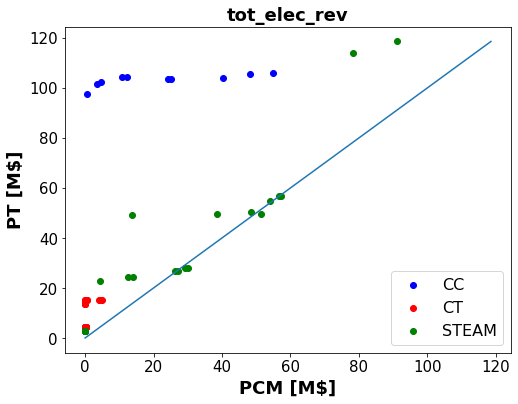

In [29]:
font1 = {"weight": "bold", "size": 18}

def make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item):
    if item in ["tot_elec_rev", "tot_op_cost", "tot_profit"]:
        factor = 1e6
        unit = "M$"
    if item == "tot_dispatch":
        factor = 1e3
        unit = "GWh"
    if item == "num_startup":
        factor =1
        unit = "#"
    color = {"CC": "b", "CT": "r", "STEAM": "g"}
    fig, ax = plt.subplots(figsize=(8, 6))
    for f in gen_forms:
        item_pt = []
        item_pcm = []
        for name in gen_forms[f]:
            y = df_all_gen_summarize_PT[df_all_gen_summarize_PT.index==name][item]/factor
            x = df_all_gen_summarize_PCM[df_all_gen_summarize_PCM.index==name][item]/factor
            item_pt.append(y)
            item_pcm.append(x)
#             ax.text(x, y*1.05, name)
        ax.scatter(item_pcm, item_pt, c=color[f], label=f)
#         for name in gen_forms[f]:
            # x: PCM, y: PT
#             plt.scatter(df_all_gen_summarize_PCM.loc[name][item], df_all_gen_summarize_PT.loc[name][item], c=color[f])
            
    # plot y = x
    minimum = min(df_all_gen_summarize_PCM[item].min()/factor, df_all_gen_summarize_PT[item].min()/factor)
    maximum = max(df_all_gen_summarize_PCM[item].max()/factor, df_all_gen_summarize_PT[item].max()/factor)
    x = np.linspace(minimum, maximum)
    ax.plot(x,x)
    ax.set_xlabel(f"PCM [{unit}]", font=font1)
    ax.set_ylabel(f"PT [{unit}]", font=font1)
    ax.set_title(f"{item}", font=font1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(prop={"size": 16})
    
    return

make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item='tot_elec_rev')

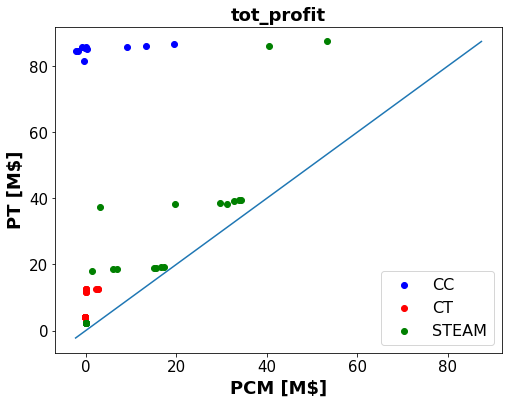

In [23]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item='tot_profit')

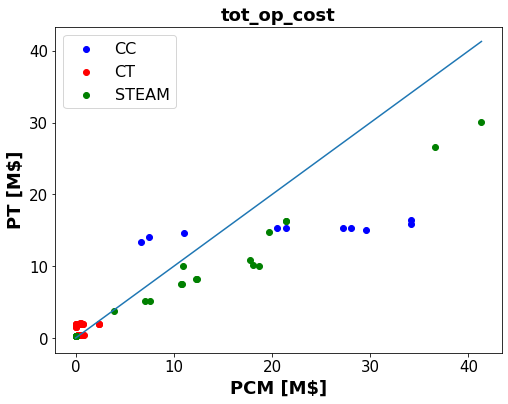

In [25]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="tot_op_cost")

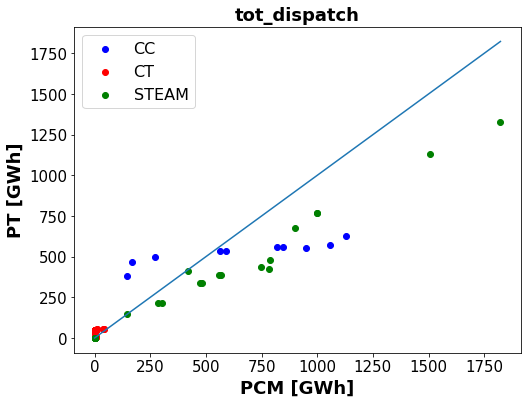

In [26]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="tot_dispatch")

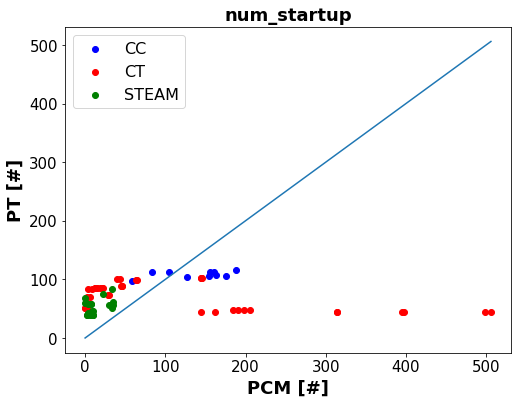

In [27]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="num_startup")

## Detailed generator level analysis

In [43]:
df_all_gen_summarize_PT.loc["101_CT_1"]

tot_dispatch        3.316000e+03
tot_elec_rev        4.407069e+06
tot_op_cost         3.942242e+05
tot_startup_cost    2.328615e+03
tot_profit          4.010517e+06
num_startup         4.500000e+01
Name: 101_CT_1, dtype: float64

In [48]:
def print_results(df_all_gen_summarize_PT, df_all_gen_summarize_PCM, item):
    print("Gen Name    ",  f"PT_{item}    ", f"PCM_{item}")
    for name in gen_dict["fossil"].keys():
        pt_res = np.round(df_all_gen_summarize_PT.loc[name][item], 2)
        pcm_res = np.round(df_all_gen_summarize_PCM.loc[name][item], 2)
        print(name, "    ", pt_res, "    ",  pcm_res)
    return

print_results(df_all_gen_summarize_PT, df_all_gen_summarize_PCM, item="tot_profit")

Gen Name     PT_tot_profit     PCM_tot_profit
101_CT_1      4010516.65      -420309.18
101_CT_2      4010516.65      -452714.74
101_STEAM_3      19117329.97      17511622.67
101_STEAM_4      19117329.97      17580543.55
102_CT_1      3993201.54      -87349.99
102_CT_2      3993201.54      -122388.3
102_STEAM_3      18859154.81      17512509.66
102_STEAM_4      18859154.81      17490453.31
107_CC_1      85438216.59      1101827.1
113_CT_1      12340781.79      -100448.71
113_CT_2      12340781.79      -101922.95
113_CT_3      12340781.79      -117635.81
113_CT_4      12340781.79      -152509.43
115_STEAM_1      2299404.16      -38552.16
115_STEAM_2      2299404.16      -34041.58
115_STEAM_3      38171532.95      32204624.81
116_STEAM_1      37520094.47      1825086.62
118_CC_1      85264205.22      -3939172.65
123_STEAM_2      38571299.62      35362992.93
123_STEAM_3      85971178.74      46951433.14
123_CT_1      12376436.44      -375350.57
123_CT_4      12376436.44      -380135.76
123

### Calculate capacity factors

In [28]:
def calculate_cf(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_dict, gen_name):
    pmax = gen_dict["fossil"][gen_name]["max_p"]
    pt_cf = df_all_gen_summarize_PT.loc[gen_name]["tot_dispatch"]/pmax/8784
    pcm_cf = df_all_gen_summarize_PCM.loc[gen_name]["tot_dispatch"]/pmax/8784
    
    return pt_cf, pcm_cf

pt_cf_dict = {}
pcm_cf_dict = {}
diff_cf_dict = {}    # (pt-pcm)/pcm
for name in gen_names:
    pt_cf, pcm_cf = calculate_cf(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_dict, gen_name=name)
    pt_cf_dict[name] = pt_cf
    pcm_cf_dict[name] = pcm_cf
    diff_cf_dict[name] = (pt_cf - pcm_cf)/pcm_cf

summarize_cf_dict = {"GO":[], "SO":[], "NO":[], "NU":[], "SU":[], "GU":[]}
for key, value in diff_cf_dict.items():
    if value > 1:
        summarize_cf_dict["GO"].append(key)
    if (0.2 < value) and (value <= 1):
        summarize_cf_dict["SO"].append(key)
    if (0.0 < value) and (value <= 0.2):
        summarize_cf_dict["NO"].append(key)
    if (-0.2 < value) and (value <= 0.0):
        summarize_cf_dict["NU"].append(key)
    if (-1.0 < value) and (value <= -0.2):
        summarize_cf_dict["SU"].append(key)
    if value <= -1:
        summarize_cf_dict["GU"].append(key)
    
# summarize_cf_dict

C:\Users\JKLCh\AppData\Local\Temp\ipykernel_19180\3009771151.py:15: RuntimeWarning: divide by zero encountered in double_scalars
  diff_cf_dict[name] = (pt_cf - pcm_cf)/pcm_cf


In [38]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["GO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
102_CT_1     1.6186     0.0186     0.0071     10.3494
102_CT_2     1.321     0.0186     0.008     10.3494
113_CT_1     33.4193     0.1003     0.0029     3.88722
113_CT_2     33.6902     0.1003     0.0029     3.88722
113_CT_3     27.986     0.1003     0.0035     3.88722
113_CT_4     22.3127     0.1003     0.0043     3.88722
115_STEAM_1     8.34     0.0177     0.0019     10.3494
115_STEAM_2     8.9893     0.0177     0.0018     10.3494
123_CT_1     7.3449     0.1021     0.0122     3.88722
123_CT_4     7.1009     0.1021     0.0126     3.88722
123_CT_5     7.1332     0.1021     0.0126     3.88722
207_CT_1     12.9896     0.0917     0.0066     3.88722
207_CT_2     12.9896     0.0917     0.0066     3.88722
213_CT_1     25.1282     0.1003     0.0038     3.88722
213_CT_2     27.8521     0.1003     0.0035     3.88722
215_CT_4     136.5484     0.0971     0.0007     3.88722
215_CT_5     49.707     0.0971     0.0019     3.88722
218_CC_1    

In [37]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["SO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
213_CC_3     0.8368     0.1605     0.0874     3.88722
302_CT_1     0.8428     0.0192     0.0104     10.3494
302_CT_2     0.8673     0.0192     0.0103     10.3494
315_CT_6     0.4372     0.1162     0.0808     3.88722
315_CT_7     0.3934     0.1162     0.0834     3.88722
315_CT_8     0.3776     0.1162     0.0843     3.88722


In [36]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["NO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
201_CT_1     0.1044     0.0193     0.0174     10.3494
201_CT_2     0.1073     0.0193     0.0174     10.3494
201_STEAM_3     0.0305     0.2217     0.2152     2.11399


In [35]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["NU"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
116_STEAM_1     -0.0222     0.3003     0.3072     2.11399
202_CT_1     -0.1689     0.0198     0.0239     10.3494
202_CT_2     -0.1783     0.0198     0.0241     10.3494
323_CC_1     -0.0542     0.1713     0.1811     3.88722
323_CC_2     -0.0949     0.1713     0.1893     3.88722


In [34]:
# check the level of under/overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["SU"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_CT_1     -0.4099     0.0189     0.032     10.3494
101_CT_2     -0.4254     0.0189     0.0328     10.3494
101_STEAM_3     -0.3112     0.5839     0.8477     2.11399
101_STEAM_4     -0.3051     0.5839     0.8402     2.11399
102_STEAM_3     -0.2954     0.5083     0.7214     2.11399
102_STEAM_4     -0.2865     0.5083     0.7125     2.11399
107_CC_1     -0.3151     0.1799     0.2627     3.88722
115_STEAM_3     -0.4189     0.3199     0.5504     2.11399
118_CC_1     -0.3358     0.1798     0.2708     3.88722
123_STEAM_2     -0.3906     0.353     0.5793     2.11399
123_STEAM_3     -0.2506     0.3671     0.4899     2.11399
202_STEAM_3     -0.2886     0.3249     0.4568     2.11399
202_STEAM_4     -0.2394     0.3249     0.4272     2.11399
216_STEAM_1     -0.2471     0.4975     0.6609     2.11399
221_CC_1     -0.4463     0.2003     0.3618     3.88722
223_STEAM_1     -0.2322     0.5641     0.7347     2.11399
223_STEAM_2     -0.2317     0.

In [46]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["CC"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}")

Gen name     Diff rate     PT CF     PCM CF
107_CC_1     -0.3151     0.1799     0.2627
118_CC_1     -0.3358     0.1798     0.2708
213_CC_3     0.8368     0.1605     0.0874
218_CC_1     1.6178     0.1216     0.0464
221_CC_1     -0.4463     0.2003     0.3618
313_CC_1     -0.4618     0.1827     0.3396
318_CC_1     1.8151     0.1507     0.0535
321_CC_1     -0.4167     0.1778     0.3048
323_CC_1     -0.0542     0.1713     0.1811
323_CC_2     -0.0949     0.1713     0.1893


In [39]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["CT"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_CT_1     -0.4099     0.0189     0.032     10.3494
101_CT_2     -0.4254     0.0189     0.0328     10.3494
102_CT_1     1.6186     0.0186     0.0071     10.3494
102_CT_2     1.321     0.0186     0.008     10.3494
113_CT_1     33.4193     0.1003     0.0029     3.88722
113_CT_2     33.6902     0.1003     0.0029     3.88722
113_CT_3     27.986     0.1003     0.0035     3.88722
113_CT_4     22.3127     0.1003     0.0043     3.88722
123_CT_1     7.3449     0.1021     0.0122     3.88722
123_CT_4     7.1009     0.1021     0.0126     3.88722
123_CT_5     7.1332     0.1021     0.0126     3.88722
201_CT_1     0.1044     0.0193     0.0174     10.3494
201_CT_2     0.1073     0.0193     0.0174     10.3494
202_CT_1     -0.1689     0.0198     0.0239     10.3494
202_CT_2     -0.1783     0.0198     0.0241     10.3494
207_CT_1     12.9896     0.0917     0.0066     3.88722
207_CT_2     12.9896     0.0917     0.0066     3.88722
213_CT_1     25.1

In [40]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["STEAM"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_STEAM_3     -0.3112     0.5839     0.8477     2.11399
101_STEAM_4     -0.3051     0.5839     0.8402     2.11399
102_STEAM_3     -0.2954     0.5083     0.7214     2.11399
102_STEAM_4     -0.2865     0.5083     0.7125     2.11399
115_STEAM_1     8.34     0.0177     0.0019     10.3494
115_STEAM_2     8.9893     0.0177     0.0018     10.3494
115_STEAM_3     -0.4189     0.3199     0.5504     2.11399
116_STEAM_1     -0.0222     0.3003     0.3072     2.11399
123_STEAM_2     -0.3906     0.353     0.5793     2.11399
123_STEAM_3     -0.2506     0.3671     0.4899     2.11399
201_STEAM_3     0.0305     0.2217     0.2152     2.11399
202_STEAM_3     -0.2886     0.3249     0.4568     2.11399
202_STEAM_4     -0.2394     0.3249     0.4272     2.11399
216_STEAM_1     -0.2471     0.4975     0.6609     2.11399
223_STEAM_1     -0.2322     0.5641     0.7347     2.11399
223_STEAM_2     -0.2317     0.5641     0.7342     2.11399
223_STEAM_3     -0.

In [20]:
# No dispatch
df_all_gen_summarize_PCM[df_all_gen_summarize_PCM["tot_elec_rev"]==0]

,tot_elec_rev,tot_dispatch,tot_op_cost,tot_profit,num_startup
223_CT_5,0.0,0.0,0.0,0.0,0
223_CT_6,0.0,0.0,0.0,0.0,0


In [21]:
df_all_gen_summarize_PCM.loc["322_CT_6"], df_all_gen_summarize_PT.loc["322_CT_6"]

(tot_elec_rev    341288.447985
 tot_dispatch      9844.542912
 tot_op_cost     768252.317417
 tot_profit     -426963.869432
 num_startup         65.000000
 Name: 322_CT_6, dtype: float64,
 tot_dispatch        5.328400e+04
 tot_elec_rev        1.507211e+07
 tot_op_cost         1.925696e+06
 tot_startup_cost    5.608582e+05
 tot_profit          1.258556e+07
 num_startup         9.900000e+01
 Name: 322_CT_6, dtype: float64)

## Check the marginal cost of generators

In [7]:
for name in gen_dict["fossil"].keys():
    print(name, "    ", gen_dict["fossil"][name]["fuel_p"])


101_CT_1      10.3494
101_CT_2      10.3494
101_STEAM_3      2.11399
101_STEAM_4      2.11399
102_CT_1      10.3494
102_CT_2      10.3494
102_STEAM_3      2.11399
102_STEAM_4      2.11399
107_CC_1      3.88722
113_CT_1      3.88722
113_CT_2      3.88722
113_CT_3      3.88722
113_CT_4      3.88722
115_STEAM_1      10.3494
115_STEAM_2      10.3494
115_STEAM_3      2.11399
116_STEAM_1      2.11399
118_CC_1      3.88722
123_STEAM_2      2.11399
123_STEAM_3      2.11399
123_CT_1      3.88722
123_CT_4      3.88722
123_CT_5      3.88722
201_CT_1      10.3494
201_CT_2      10.3494
201_STEAM_3      2.11399
202_CT_1      10.3494
202_CT_2      10.3494
202_STEAM_3      2.11399
202_STEAM_4      2.11399
207_CT_1      3.88722
207_CT_2      3.88722
213_CC_3      3.88722
213_CT_1      3.88722
213_CT_2      3.88722
215_CT_4      3.88722
215_CT_5      3.88722
216_STEAM_1      2.11399
218_CC_1      3.88722
221_CC_1      3.88722
223_STEAM_1      2.11399
223_STEAM_2      2.11399
223_STEAM_3      2.11399
223